In [130]:
from pynq import PL
PL.reset() #important fixes caching issues which have popped up.
import xrfdc #poorly documented library that handles interfacing to the RF data converter
from pynq import Overlay  #import the overlay module
ol = Overlay('./design_1_decode.bit')  #locate/point to the bit file
import pprint
pprint.pprint(ol.ip_dict)
dma = ol.axi_dma_0 #might need to change name depending on what you called it
rf = ol.usp_rf_data_converter_0 #might need to change name depending on what you called it
from pynq import Clocks
Clocks.pl_clk0_mhz = 150
print(Clocks.pl_clk0_mhz)

{'axi_dma_0': {'addr_range': 65536,
               'bdtype': None,
               'device': <pynq.pl_server.embedded_device.EmbeddedDevice object at 0xffffac35ce50>,
               'driver': <class 'pynq.lib.dma.DMA'>,
               'fullpath': 'axi_dma_0',
               'gpio': {},
               'interrupts': {},
               'mem_id': 'S_AXI_LITE',
               'memtype': 'REGISTER',
               'parameters': {'ADDR_WIDTH': '10',
                              'ARUSER_WIDTH': '0',
                              'AWUSER_WIDTH': '0',
                              'BUSER_WIDTH': '0',
                              'CLK_DOMAIN': 'design_1_zynq_ultra_ps_e_0_0_pl_clk0',
                              'C_BASEADDR': '0xA0000000',
                              'C_DLYTMR_RESOLUTION': '125',
                              'C_ENABLE_MULTI_CHANNEL': '0',
                              'C_FAMILY': 'zynquplus',
                              'C_HIGHADDR': '0xA000FFFF',
                          

                                                                                   'an '
                                                                                   'invalid '
                                                                                   'address. '
                                                                                   'This '
                                                                                   'error '
                                                                                   'condition '
                                                                                   'causes '
                                                                                   'the '
                                                                                   'AXI '
                                                                                   'DMA '
                                                                                

                                            'C_DAC_Neg_Quadrature33': 'false',
                                            'C_DAC_Nyquist00': '0',
                                            'C_DAC_Nyquist01': '0',
                                            'C_DAC_Nyquist02': '0',
                                            'C_DAC_Nyquist03': '0',
                                            'C_DAC_Nyquist10': '0',
                                            'C_DAC_Nyquist11': '0',
                                            'C_DAC_Nyquist12': '0',
                                            'C_DAC_Nyquist13': '0',
                                            'C_DAC_Nyquist20': '0',
                                            'C_DAC_Nyquist21': '0',
                                            'C_DAC_Nyquist22': '0',
                                            'C_DAC_Nyquist23': '0',
                                            'C_DAC_Nyquist30': '0',
                                     

                                      'PSU__DDRC__TRAIN_DATA_EYE': '1',
                                      'PSU__DDRC__TRAIN_READ_GATE': '1',
                                      'PSU__DDRC__TRAIN_WRITE_LEVEL': '1',
                                      'PSU__DDRC__T_FAW': '30.0',
                                      'PSU__DDRC__T_RAS_MIN': '32.0',
                                      'PSU__DDRC__T_RC': '45.32',
                                      'PSU__DDRC__T_RCD': '16',
                                      'PSU__DDRC__T_RP': '16',
                                      'PSU__DDRC__VENDOR_PART': 'OTHERS',
                                      'PSU__DDRC__VIDEO_BUFFER_SIZE': '0',
                                      'PSU__DDRC__VREF': '1',
                                      'PSU__DDR_HIGH_ADDRESS_GUI_ENABLE': '1',
                                      'PSU__DDR_QOS_ENABLE': '0',
                                      'PSU__DDR_QOS_FIX_HP0_RDQOS': None,
                     

In [131]:
adc_tile = rf.adc_tiles[2]
print(adc_tile)
adc_block = adc_tile.blocks[0]
print(adc_block)
print(adc_block.BlockStatus)
print(adc_block.MixerSettings)
adc_block.Dither = 0 #doesn't really matter for this lab, but let's turn off.
center_frequency = 61.25055 #Target a radio station you found last week with this (MIT is 88.1... 96.9 is HOT, 100.7 is classic rock, etc...)
adc_block.MixerSettings['Freq']= center_frequency # set the frequency of the Numerically controlled oscillator.
adc_block.UpdateEvent(xrfdc.EVENT_MIXER) #every time setting is changed, must call this.
print(adc_block.MixerSettings)

{'SamplingFreq': 1.024, 'AnalogDataPathStatus': 1, 'DigitalDataPathStatus': 769, 'DataPathClocksStatus': 1, 'IsFIFOFlagsEnabled': 3, 'IsFIFOFlagsAsserted': 0}
{'Freq': 62.150000000001455, 'PhaseOffset': 0.0, 'EventSource': 2, 'CoarseMixFreq': 16, 'MixerMode': 3, 'FineMixerScale': 0, 'MixerType': 2}
{'Freq': 61.25054999999702, 'PhaseOffset': 0.0, 'EventSource': 2, 'CoarseMixFreq': 0, 'MixerMode': 3, 'FineMixerScale': 0, 'MixerType': 2}


In [132]:

def build_frame_from_samples(samples, num_lines=240, pixels_per_line=421):
    """
    Convert a flat list of (trigger, oddeven, state, pixel) tuples
    into a 2-D numpy array [lines, pixels].

    Algorithm:
      - Each colorburst trigger (trigger=1) indicates the end of colorburst and start of active video
      - When trigger goes high, start collecting pixels for a new line
      - Collect exactly pixels_per_line pixels per line (421 for NTSC)
      - Collect exactly num_lines lines (240 for NTSC active video)
    """

    lines = []
    cur_line = []
    collecting = False  # Are we currently collecting pixels for a line?

    for trigger, oddeven, state, pixel in samples:
        # Detect rising edge of colorburst trigger - marks start of active video line
        if trigger:
            # If we were collecting, save the previous line (truncate/pad to pixels_per_line)
            if collecting:
                # Truncate or pad to exactly pixels_per_line
                if len(cur_line) > pixels_per_line:
                    cur_line = cur_line[:pixels_per_line]
                elif len(cur_line) < pixels_per_line:
                    cur_line.extend([0] * (pixels_per_line - len(cur_line)))
                lines.append(cur_line)
                
                # Stop if we have enough lines
                if len(lines) >= num_lines:
                    break
            
            # Start collecting pixels for new line
            cur_line = []
            collecting = True
            # Don't add the trigger sample itself as a pixel
            continue

        # Collect pixels when we're in collecting mode and in valid decode states
        # Only collect up to pixels_per_line pixels per line
        if collecting and state >= 2:
            if len(cur_line) < pixels_per_line:
                cur_line.append(pixel)
            # If we've collected enough pixels, wait for next trigger
            # (but keep collecting flag set so we save the line on next trigger)

    # Push last line if we were still collecting and need more lines
    if collecting and cur_line and len(lines) < num_lines:
        # Truncate or pad to exactly pixels_per_line
        if len(cur_line) > pixels_per_line:
            cur_line = cur_line[:pixels_per_line]
        elif len(cur_line) < pixels_per_line:
            cur_line.extend([0] * (pixels_per_line - len(cur_line)))
        lines.append(cur_line)

    # Create image with exact dimensions
    if not lines:
        return np.zeros((num_lines, pixels_per_line), dtype=np.uint8)

    # Ensure we have exactly num_lines (pad with black lines if needed)
    while len(lines) < num_lines:
        lines.append([0] * pixels_per_line)
    
    # Truncate if we have too many lines
    lines = lines[:num_lines]
    
    # Create image - each line should already be exactly pixels_per_line
    img = np.zeros((num_lines, pixels_per_line), dtype=np.uint8)
    for i, line in enumerate(lines):
        n = min(len(line), pixels_per_line)
        if n > 0:
            img[i, :n] = line[:n]

    return img

In [118]:
def make_threshold_regs(
    vsync_lb=170,
    vsync_ub=185,
    vsync_samples_lb=210,
    black_level=150,
    white_level=40,
    hsync_lb=183,          # adjust to 182 if you prefer that value
    hsync_ub=190,
    hsync_samples_lb=40,   # adjust to 33 if you prefer that value
    cb_lb=128,
    cb_ub=145,
    cb_samples_ub=25,
    oddeven_th=85,
):
    """
    Build slvreg0, slvreg1, slvreg2 to match the HDL:

        assign MMIO_thresholds = {slvreg0, slvreg1, slvreg2};

    Byte layout on MMIO_thresholds (LSB first):

      Byte 0  -> vsync_lb_threshold          (MMIO[7:0])
      Byte 1  -> vsync_ub_threshold          (MMIO[15:8])
      Byte 2  -> vsync_samples_lb_threshold  (MMIO[23:16])
      Byte 3  -> black_level_default         (MMIO[31:24])

      Byte 4  -> white_level_default         (MMIO[39:32])
      Byte 5  -> hsync_lb_threshold          (MMIO[47:40])
      Byte 6  -> hsync_ub_threshold          (MMIO[55:48])
      Byte 7  -> hsync_samples_lb_threshold  (MMIO[63:56])

      Byte 8  -> cb_lb_threshold             (MMIO[71:64])
      Byte 9  -> cb_ub_threshold             (MMIO[79:72])
      Byte 10 -> cb_samples_ub_threshold     (MMIO[87:80])
      Byte 11 -> oddeven_th_threshold        (MMIO[95:88])

    Returns:
        (slvreg0, slvreg1, slvreg2) as 32-bit integers.
    """

    threshold_bytes = [
        vsync_lb,
        vsync_ub,
        vsync_samples_lb,
        black_level,
        white_level,
        hsync_lb,
        hsync_ub,
        hsync_samples_lb,
        cb_lb,
        cb_ub,
        cb_samples_ub,
        oddeven_th,
    ]

    def pack_word(b0, b1, b2, b3):
        # Little-endian within each 32-bit word,
        # so b0 -> bits [7:0], b1 -> [15:8], etc.
        return (
            (b0 & 0xFF)
            | ((b1 & 0xFF) << 8)
            | ((b2 & 0xFF) << 16)
            | ((b3 & 0xFF) << 24)
        )

    # Match MMIO_thresholds = {slvreg0, slvreg1, slvreg2}
    # MMIO[31:0] = slvreg2  -> bytes 0..3
    # MMIO[63:32] = slvreg1 -> bytes 4..7
    # MMIO[95:64] = slvreg0 -> bytes 8..11
    slvreg2 = pack_word(*threshold_bytes[0:4])   # vsync + black
    slvreg1 = pack_word(*threshold_bytes[4:8])   # white + hsync
    slvreg0 = pack_word(*threshold_bytes[8:12])  # cb + oddeven

    return slvreg0, slvreg1, slvreg2

def program_thresholds(j5):
    """
    Write threshold registers via AXI-Lite MMIO.

    base_offset should be the byte offset of slvreg0.
    Then:
        slvreg0 -> base_offset + 0x0
        slvreg1 -> base_offset + 0x4
        slvreg2 -> base_offset + 0x8
    """
    slvreg0, slvreg1, slvreg2 = make_threshold_regs()
    
    j5.write(0x0, slvreg0)  # slvreg0
    j5.write(0x4, slvreg1)  # slvreg1
    j5.write(0x8, slvreg2)  # slvreg2





In [133]:
print(ol.ip_dict.keys())
j5 = ol.mmio_interface_0

program_thresholds(j5)

d = j5.read(0x04)
print(d)
# turn into 8 bits each and print out thresholds to ensure that they are correctly set


dict_keys(['axi_dma_0', 'mmio_interface_0', 'usp_rf_data_converter_0', 'zynq_ultra_ps_e_0'])
683587368


Hardware execution time:  0.022112369537353516
lines collected:  114
v sync


<IPython.core.display.Javascript object>


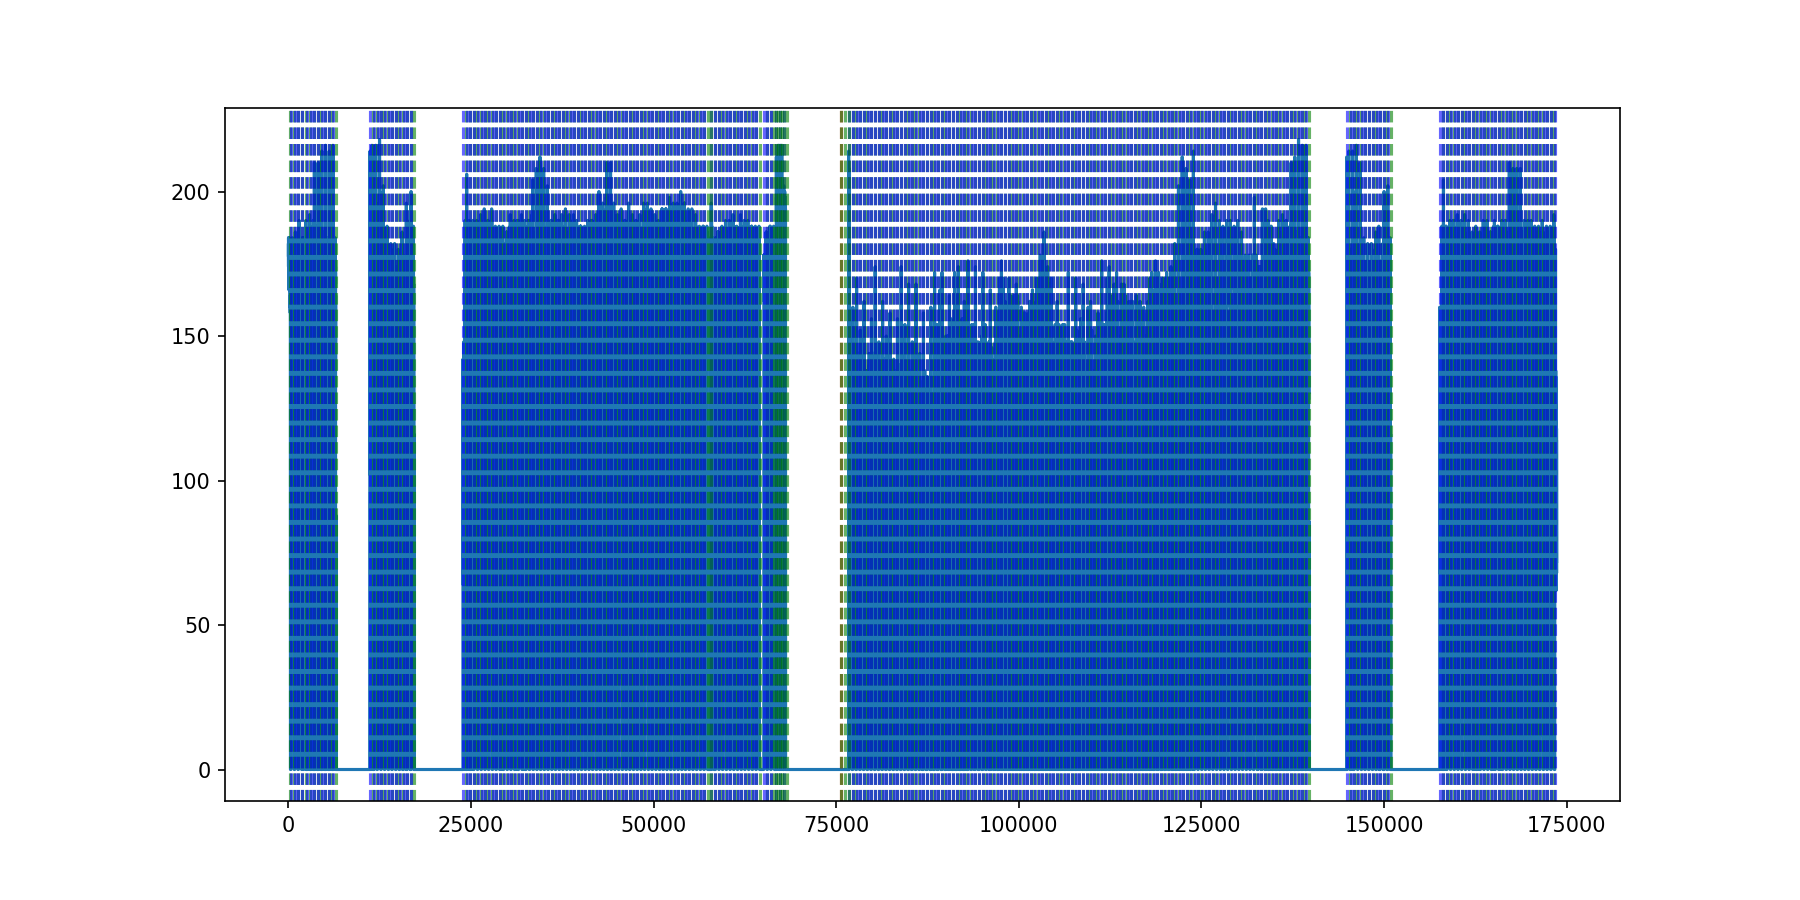

<IPython.core.display.Javascript object>


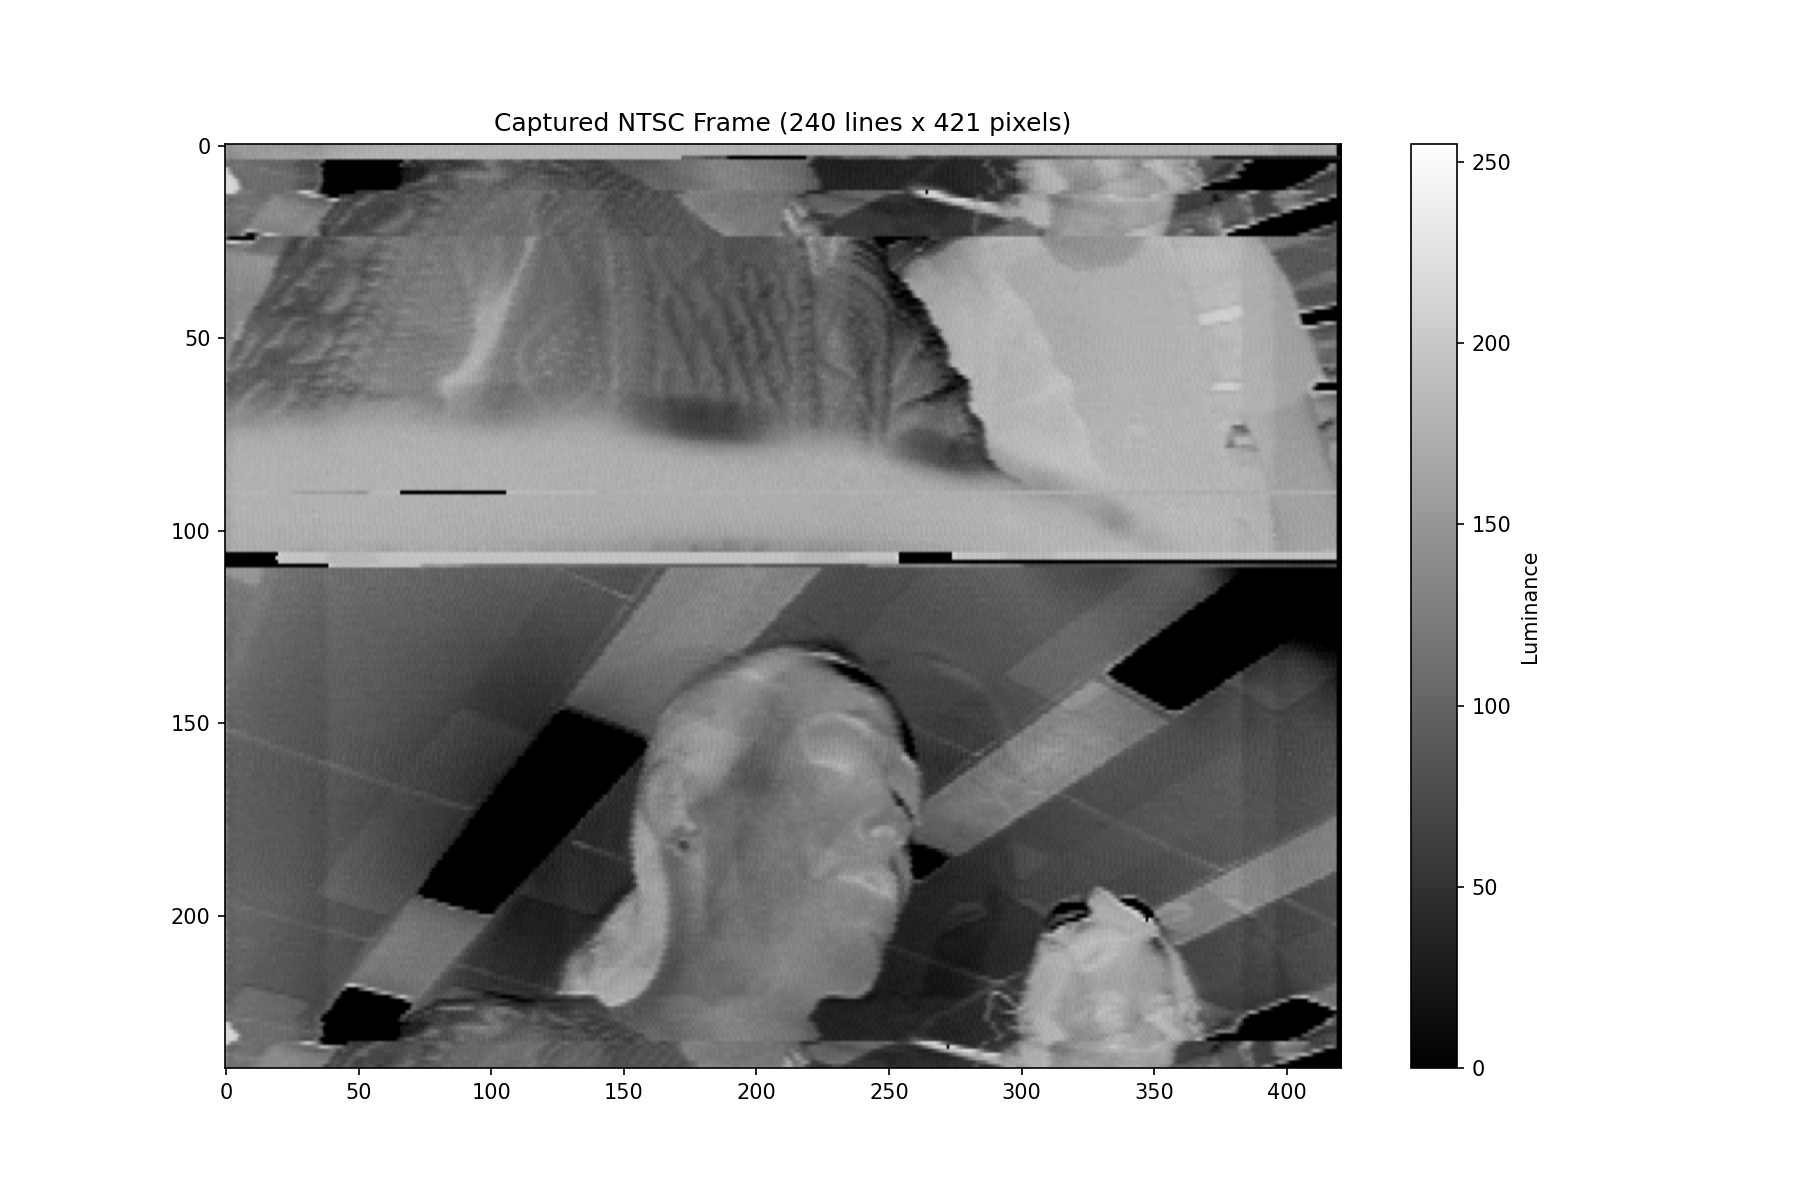

In [137]:
import numpy as np
import time
import bitstring
%matplotlib notebook
import matplotlib.pyplot as plt
from pynq import allocate
from pathlib import Path

def plot_to_notebook(time_sec,in_signal,n_samples,):
    plt.figure()
    plt.subplot(1, 1, 1)
    plt.xlabel('Time (usec)')
    plt.grid()
    plt.plot(time_sec[:n_samples]*1e6,in_signal[:n_samples],'y-o',label='Input signal')
    #plt.plot(time_sec[:n_samples]*1e6,in_signal[:n_samples],'y-o',label='Input signal')

    plt.legend()
def iq_plot(time_sec,re_signal,im_signal,n_samples,):
    plt.figure()
    plt.subplot(1, 1, 1)
    plt.xlabel('Time (usec)')
    plt.grid()
    plt.plot(time_sec[:n_samples],re_signal[:n_samples],'y-o',label='I signal')
    plt.plot(time_sec[:n_samples],im_signal[:n_samples],'g-o',label='Q signal')
    #plt.plot(time_sec[:n_samples]*1e6,in_signal[:n_samples],'y-o',label='Input signal')
    plt.legend()

def plot_fft(samples,in_signal,n_samples,):
    plt.figure()
    plt.subplot(1, 1, 1)
    plt.xlabel('Frequency')
    plt.grid()
    plt.plot(samples[:n_samples],in_signal[:n_samples],'y-',label='Signal')
    #plt.plot(time_sec[:n_samples]*1e6,in_signal[:n_samples],'y-',label='Signal')
    plt.legend()
    
# def plot_mag(real)
# Sampling frequency
fs = 8 #8MHz - new for this week (250 ksps)
# Number of samples
n = 262134 #new for this week (maybe)
T = n/fs
down_from_center = center_frequency - fs/2
up_from_center = center_frequency + fs/2
# Time vector in seconds
t = np.linspace(0, T, n, endpoint=False)
# Allocate buffers for the input and output signals
ns = np.linspace(down_from_center, up_from_center,n,endpoint=False)
out_buffer = allocate(400024, dtype=np.int32) #more than big enough to hold ~quarter million samples
# Trigger the DMA transfer and wait for the result
start_time = time.time()
dma.recvchannel.transfer(out_buffer)
dma.recvchannel.wait()
stop_time = time.time()
hw_exec_time = stop_time-start_time
print('Hardware execution time: ',hw_exec_time)

## FOR DATA ACQUISITION
# imag = np.array([np.int16(out_buffer[i]&0xFFFF) for i in range(n)])
# real = np.array([np.int16(out_buffer[i]>>16) for i in range(n)])
# out_buffer.close()
# iq_plot(t,real,imag,30000)
# c_data = real + 1j*imag #make complex data
# #c_data = 0.5*np.angle(c_data[0:-1]*np.conj(c_data[1:])) #demodulate
# z = np.fft.fftshift(np.fft.fft(c_data,n))
# plot_fft(ns,abs(z),n)

# plotting the magintude of i and q
# plot_to_notebook(t, abs(c_data), 30000)
# magnitudes = []
# for im, re in zip(imag, real):
#     magnitudes.append((im**2+re**2)**(1/2))
# plt.figure()
# plt.grid()
# plt.plot(magnitudes)
# plt.show()

## FOR CORDIC OUTPUT
# magnitudes = []

# for val in out_buffer:
#     # Mask to 32 bits in case val is negative
#     word = val & 0xFFFFFFFF

#     # Extract unsigned magnitude (lower 16 bits)
#     mag = word & 0xFFFF

#     magnitudes.append(mag)
    
# plt.plot(magnitudes)

## FOR SYNC DETECTOR OUTPUT
# magnitudes = []
# states = []
# oddeven_list = []
# cb_trigger_list = []
# vsync_list = []
# hsync_list = []
# prev_state = 0
# line_count = 0

# for val in out_buffer:
#     if (val != 0):
#         word = val & 0xFFFFFFFF   # ensure 32-bit unsigned

#         # bottom 16 bits
#         mag = word & 0xFFFF

#         # next 3 bits (bits 16,17,18)
#         state = (word >> 16) & 0b111

#         # bit 19
#         oddeven = (word >> 19) & 0b1

#         # bit 20
#         trigger = (word >> 20) & 0b1

#         magnitudes.append(mag)
#         states.append(state)
#         oddeven_list.append(oddeven)
#         cb_trigger_list.append(trigger)
        
        
#         ## detect vertical syncs
#         if (state == 2 & state != prev_state):
#             print("lines collected: ", line_count)
#             line_count = 0
#             print("v sync")
#             vsync_list.append(1)
#         else:
#             vsync_list.append(0)

#         ## count number of lines between vertical syncs, should be 220 i think
#         if (state == 3 & state != prev_state):
#             line_count += 1
#             hsync_list.append(1)
#         else:
#             hsync_list.append(0)

#         prev_state = state
    
    
# plt.figure(figsize=(12, 6))

# # Plot magnitude as a line
# plt.plot(magnitudes, label='Magnitude')

# # Add vertical bars at trigger points
# for i in range(len(magnitudes)):
#     if vsync_list[i] == 1:
#         plt.axvline(x=i, color='r', linestyle='--', alpha=0.6)
#     if cb_trigger_list[i] == 1:
#         plt.axvline(x=i, color='b', linestyle='--', alpha=0.6)
#     if hsync_list[i] == 1:
#         plt.axvline(x=i, color='g', linestyle='--', alpha=0.6)

# plt.xlabel('Sample Index')
# plt.ylabel('Magnitude')
# plt.title('Magnitudes with Trigger Events')
# plt.legend(loc="upper right")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


    


## FOR VIDEO DECODE OUTPUT
luminance = []
states = []
oddeven_list = []
cb_trigger_list = []
vsync_list = []
hsync_list = []
prev_state = 0
line_count = 0

for val in out_buffer:
    if (val != 0):
        word = val & 0xFFFFFFFF   # ensure 32-bit unsigned

        # bottom 16 bits
        lum = word & 0xFF

        # next 3 bits (bits 8, 9, 10)
        state = (word >> 8) & 0b111

        # bit 11
        oddeven = (word >> 11) & 0b1

        # bit 12
        trigger = (word >> 12) & 0b1

        luminance.append(lum)
        states.append(state)
        oddeven_list.append(oddeven)
        cb_trigger_list.append(trigger)
        
        
        ## detect vertical syncs
        if (state == 2 & state != prev_state):
            print("lines collected: ", line_count)
            line_count = 0
            print("v sync")
            vsync_list.append(1)
        else:
            vsync_list.append(0)

        ## count number of lines between vertical syncs, should be 220 i think
        if (state == 3 & state != prev_state):
            line_count += 1
            hsync_list.append(1)
        else:
            hsync_list.append(0)

        prev_state = state
    
    
plt.figure(figsize=(12, 6))

# Plot magnitude as a line
plt.plot(luminance, label='Luminance')

# Add vertical bars at trigger points
for i in range(len(luminance)):
    if vsync_list[i] == 1:
        plt.axvline(x=i, color='r', linestyle='--', alpha=0.6)
    if cb_trigger_list[i] == 1:
        plt.axvline(x=i, color='b', linestyle='--', alpha=0.6)
    if hsync_list[i] == 1:
        plt.axvline(x=i, color='g', linestyle='--', alpha=0.6)

samples = list(zip(cb_trigger_list, oddeven_list, states, luminance))


if len(samples) > 0:
    # NTSC active video: 240 lines x 421 pixels
    frame = build_frame_from_samples(samples, num_lines=240, pixels_per_line=421)


    # Create and save image
    plt.figure(figsize=(12, 8))
    plt.imshow(frame, cmap="gray", vmin=0, vmax=255, aspect='auto')
    plt.title(f"Captured NTSC Frame ({frame.shape[0]} lines x {frame.shape[1]} pixels)")
    plt.colorbar(label='Luminance')
    plt.show()

else:
    print("No samples collected! Cannot build frame.")